# Apple Inc. (AAPL) Historical Stock Analysis
**Week 6 Advanced Python Analysis - Internship Project**

This Jupyter Notebook provides a comprehensive, end-to-end data analysis of Apple Inc. (AAPL) historical stock market data over a 5-year period. It covers data acquisition, preprocessing, cleaning, time-series analysis, feature engineering (including advanced technical indicators), and data visualization.

### Project Structure:
1. **Environment Setup & Data Acquisition**
2. **Data Exploration & Preprocessing**
3. **Data Transformation with Pandas**
4. **Time-Series Analysis**
5. **Feature Engineering**
6. **Visualizations**
7. **Key Findings & Conclusions**

## 1. Environment Setup & Data Acquisition
We begin by importing the necessary libraries. We will download 5 years of historical stock data for AAPL using the `yfinance` library. The data spans from **July 14, 2021 to July 14, 2026**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime

# Set plotting styles
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

/Users/mac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Downloading the Dataset
We download AAPL's historical data and save it as a raw CSV file to establish a clean data pipeline and lineage.

In [2]:
ticker = 'AAPL'
end_date = datetime.datetime(2026, 7, 14)
start_date = end_date - datetime.timedelta(days=5*365)

print(f'Downloading data for {ticker} from {start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}')
raw_df = yf.download(ticker, start=start_date, end=end_date)

# If columns are MultiIndex (newer yfinance versions), flatten them
if isinstance(raw_df.columns, pd.MultiIndex):
    raw_df.columns = raw_df.columns.get_level_values(0)

raw_df.to_csv('aapl_raw_data.csv')
print(f'Raw data saved to aapl_raw_data.csv. Shape: {raw_df.shape}')
raw_df.head()

[*********************100%***********************]  1 of 1 completed

Raw data saved to aapl_raw_data.csv. Shape: (1253, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-15,144.731155,146.212782,143.376251,145.471976,106820300
2021-07-16,142.693939,145.978849,142.196821,144.711683,93251400
2021-07-19,138.853394,140.432502,138.093088,140.120574,121434600
2021-07-20,142.459961,143.385987,139.350515,139.837891,96350000
2021-07-21,141.728928,142.440507,140.978379,141.855650,74993500


## 2. Data Exploration & Preprocessing
Let's explore the raw data structure, check data types, detect any missing values, and clean the data.

In [3]:
# Read raw data
df = pd.read_csv('aapl_raw_data.csv')
print('=== Data Info ===')
df.info()
print('\n=== Data Description ===')
print(df.describe())

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1253 non-null   object 
 1   Close   1253 non-null   float64
 2   High    1253 non-null   float64
 3   Low     1253 non-null   float64
 4   Open    1253 non-null   float64
 5   Volume  1253 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 58.9+ KB

=== Data Description ===
             Close         High          Low         Open        Volume
count  1253.000000  1253.000000  1253.000000  1253.000000  1.253000e+03
mean    194.854132   196.804456   192.739147   194.660333  6.499507e+07
std      45.515282    45.898101    45.126783    45.487092  2.863356e+07
min     122.933556   125.637661   122.097738   123.907048  1.791060e+07
25%     157.668472   159.677477   155.472322   157.373529  4.570480e+07
50%     183.512756   184.966868   181.722396   183.479607  

### Handling Missing Values & Data Types
We will convert the Date column to a proper datetime format, verify if there are missing values, and handle them if needed.

In [4]:
print('=== Missing Values Count ===')
print(df.isnull().sum())

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ensure date ordering is correct
df = df.sort_values(by='Date').reset_index(drop=True)

# Let's double check data types
print('\n=== Preprocessed Columns and Types ===')
print(df.dtypes)

=== Missing Values Count ===
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

=== Preprocessed Columns and Types ===
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


## 3. Data Transformation with Pandas
We perform typical Pandas transformations: renaming columns for consistency, calculating aggregate metrics, and restructuring data.

In [5]:
# Rename columns to standard snake_case for convenience
df.rename(columns={
    'Open': 'open_price',
    'High': 'high_price',
    'Low': 'low_price',
    'Close': 'close_price',
    'Adj Close': 'adj_close_price',
    'Volume': 'trading_volume'
}, inplace=True)

# Create extra calculated columns
df['daily_range'] = df['high_price'] - df['low_price']
df['vwap_proxy'] = (df['high_price'] + df['low_price'] + df['close_price']) / 3

df.to_csv('aapl_cleaned_data.csv', index=False)
print('Cleaned data saved to aapl_cleaned_data.csv')
df.head()

Cleaned data saved to aapl_cleaned_data.csv


,Date,close_price,high_price,low_price,open_price,trading_volume,daily_range,vwap_proxy
0,2021-07-15,144.731155,146.212782,143.376251,145.471976,106820300,2.836532,144.773396
1,2021-07-16,142.693939,145.978849,142.196821,144.711683,93251400,3.782028,143.623203
2,2021-07-19,138.853394,140.432502,138.093088,140.120574,121434600,2.339413,139.126328
3,2021-07-20,142.459961,143.385987,139.350515,139.837891,96350000,4.035472,141.732154
4,2021-07-21,141.728928,142.440507,140.978379,141.855650,74993500,1.462128,141.715938


### Grouping and Aggregating
Let's look at annual aggregations of Apple stock prices (Open, High, Low, Close) and total volumes to see long-term shifts.

In [6]:
df['Year'] = df['Date'].dt.year
annual_summary = df.groupby('Year').agg({
    'close_price': ['mean', 'median', 'min', 'max'],
    'trading_volume': ['mean', 'sum']
})
print('=== Annual Aggregated Statistics ===')
annual_summary

=== Annual Aggregated Statistics ===


close_price                                     trading_volume  \
            mean      median         min         max           mean   
Year                                                                  
2021  149.722234  145.484940  135.830170  176.297272   8.424548e+07   
2022  151.805449  151.057632  123.936531  177.939682   8.791038e+07   
2023  170.194614  173.282692  122.933556  195.892624   5.922355e+07   
2024  205.457394  212.424873  163.361420  257.375580   5.710678e+07   
2025  231.349891  229.226494  171.513748  285.659271   5.417578e+07   
2026  275.349044  269.981262  246.242508  317.309998   5.043787e+07   

                   
              sum  
Year               
2021  10025212200  
2022  22065504500  
2023  14805886900  
2024  14390908500  
2025  13543944600  
2026   6607361000

## 4. Time-Series Analysis
We set the Date column as index to leverage Pandas' built-in time-series tools. We will evaluate rolling windows and daily percentage returns.

In [7]:
df.set_index('Date', inplace=True)
print('Index successfully set to Date. Head of dataset:')
df.head()

Index successfully set to Date. Head of dataset:


,close_price,high_price,low_price,open_price,trading_volume,daily_range,vwap_proxy,Year
Date,,,,,,,,
2021-07-15,144.731155,146.212782,143.376251,145.471976,106820300,2.836532,144.773396,2021
2021-07-16,142.693939,145.978849,142.196821,144.711683,93251400,3.782028,143.623203,2021
2021-07-19,138.853394,140.432502,138.093088,140.120574,121434600,2.339413,139.126328,2021
2021-07-20,142.459961,143.385987,139.350515,139.837891,96350000,4.035472,141.732154,2021
2021-07-21,141.728928,142.440507,140.978379,141.855650,74993500,1.462128,141.715938,2021


### Resampling to Monthly Data
Let's aggregate the closing price and trading volume to monthly frequency to view long-term macro trends.

In [8]:
monthly_df = df.resample('ME').agg({
    'close_price': 'last',
    'open_price': 'first',
    'high_price': 'max',
    'low_price': 'min',
    'trading_volume': 'sum'
})
print('=== Monthly Resampled Data (End of Month Close and Total Volume) ===')
monthly_df.head(10)

=== Monthly Resampled Data (End of Month Close and Total Volume) ===


,close_price,open_price,high_price,low_price,trading_volume
Date,,,,,
2021-07-31,142.177322,145.471976,146.212782,138.093088,1064959400
2021-08-31,148.218338,142.664705,149.838824,141.062708,1461542800
2021-09-30,138.134033,149.194521,153.519141,137.909522,1797835100
2021-10-31,146.236603,138.524539,149.526469,134.980870,1565079200
2021-11-30,161.603409,145.445865,161.994463,144.181894,1691029000
2021-12-31,173.599030,163.734623,178.057052,154.271131,2444766700
2022-01-31,170.871384,173.853167,178.848962,151.240474,2108446000
2022-02-28,161.633087,170.118627,172.919631,148.790170,1627516300
2022-03-31,170.922699,161.221955,175.817070,146.930308,2180800100


## 5. Feature Engineering
We will engineer several financial features:
1. **Daily Price Change**: Dollar change between Close and Open.
2. **Daily Return**: Daily percentage change in closing price.
3. **Simple Moving Averages (7d, 30d, 200d)**: Captures price momentum across different horizons.
4. **Volatility (30-day Rolling Std)**: Captures risk and shifts in price volatility.
5. **Monthly Returns**: Resampled monthly return.
6. **MACD Indicator**: Differences between 12-day and 26-day Exponential Moving Averages.
7. **RSI Indicator**: Relative Strength Index to identify overbought/oversold regimes.

In [9]:
# 1. Daily Price Change (Close - Open)
df['daily_price_change'] = df['close_price'] - df['open_price']

# 2. Daily Return (percentage change)
df['daily_return'] = df['close_price'].pct_change()

# 3. Simple Moving Averages
df['7d_sma'] = df['close_price'].rolling(window=7).mean()
df['30d_sma'] = df['close_price'].rolling(window=30).mean()
df['200d_sma'] = df['close_price'].rolling(window=200).mean()

# 4. Volatility (30-day rolling standard deviation of daily returns)
df['30d_volatility'] = df['daily_return'].rolling(window=30).std() * np.sqrt(252) # Annualized

# 5. Exponential Moving Averages (EMAs) for MACD
df['12d_ema'] = df['close_price'].ewm(span=12, adjust=False).mean()
df['26d_ema'] = df['close_price'].ewm(span=26, adjust=False).mean()
df['macd'] = df['12d_ema'] - df['26d_ema']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 6. Relative Strength Index (RSI - 14-day EWM method)
delta = df['close_price'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))

# 7. Bollinger Bands (20-day SMA +/- 2 Std Dev)
df['20d_sma'] = df['close_price'].rolling(window=20).mean()
df['20d_std'] = df['close_price'].rolling(window=20).std()
df['bollinger_upper'] = df['20d_sma'] + (df['20d_std'] * 2)
df['bollinger_lower'] = df['20d_sma'] - (df['20d_std'] * 2)

print('Features successfully engineered. Head of df with features:')
df.tail(5)

Features successfully engineered. Head of df with features:


,close_price,high_price,low_price,open_price,trading_volume,daily_range,vwap_proxy,Year,daily_price_change,daily_return,...,30d_volatility,12d_ema,26d_ema,macd,macd_signal,rsi_14,20d_sma,20d_std,bollinger_upper,bollinger_lower
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-07,310.660004,315.480011,310.149994,315.290009,42490000,5.330017,312.096670,2026,-4.630005,-0.006397,...,0.336348,298.762011,296.814349,1.947661,-0.061250,60.674812,295.039999,9.172635,313.385270,276.694729
2026-07-08,313.390015,314.820007,307.049988,311.910004,41323500,7.770020,311.753337,2026,1.480011,0.008788,...,0.335382,301.012473,298.042176,2.970296,0.545060,62.247731,295.632500,9.963246,315.558993,275.706007
2026-07-09,316.220001,316.529999,308.160004,310.510010,48124500,8.369995,313.636668,2026,5.709991,0.009030,...,0.336162,303.352093,299.388682,3.963411,1.228730,63.861390,296.916000,10.884864,318.685729,275.146272
2026-07-10,315.320007,316.910004,312.170013,314.720001,34132300,4.739990,314.800008,2026,0.600006,-0.002846,...,0.335652,305.193310,300.568780,4.624530,1.907890,62.940017,298.103001,11.546656,321.196314,275.009689
2026-07-13,317.309998,323.450012,315.779999,317.019989,43214700,7.670013,318.846670,2026,0.290009,0.006311,...,0.335781,307.057416,301.808870,5.248546,2.576021,64.170933,299.187001,12.295639,323.778279,274.595723


## 6. Visualizations
We generate at least 4 premium, high-quality data visualizations to communicate our findings.

### Chart 1: Stock Closing Price Trend & Moving Averages
This chart shows the historical closing price of Apple Inc. along with its short-term (7-day), medium-term (30-day), and long-term (200-day) simple moving averages to identify crossover points and trends.

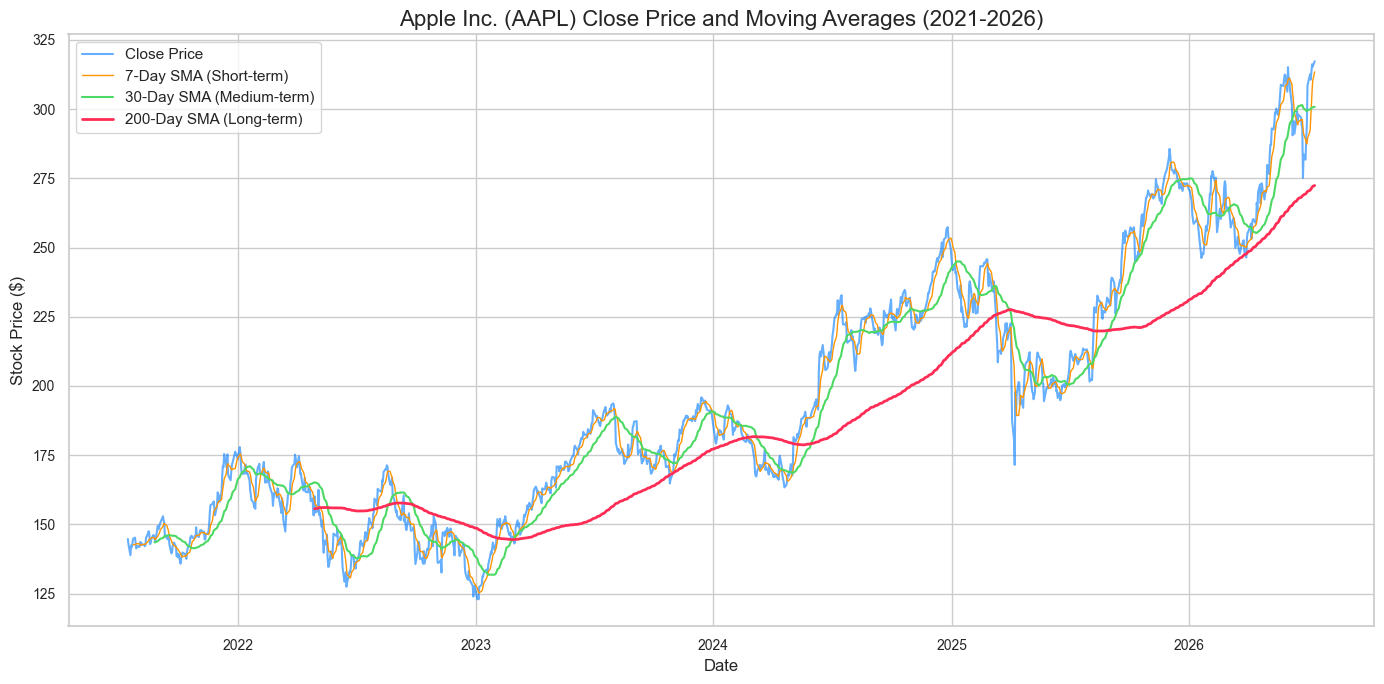

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close_price'], label='Close Price', color='#007aff', alpha=0.6, linewidth=1.5)
plt.plot(df.index, df['7d_sma'], label='7-Day SMA (Short-term)', color='#ff9500', linewidth=1)
plt.plot(df.index, df['30d_sma'], label='30-Day SMA (Medium-term)', color='#4cd964', linewidth=1.5)
plt.plot(df.index, df['200d_sma'], label='200-Day SMA (Long-term)', color='#ff2d55', linewidth=2)
plt.title('Apple Inc. (AAPL) Close Price and Moving Averages (2021-2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Stock Price ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('aapl_closing_trends.png', dpi=300)
plt.show()

### Chart 2: Trading Volume Trend
This chart tracks the daily volume traded and overlays a 30-day moving average to filter noise and reveal volume trends during high-volatility market events.

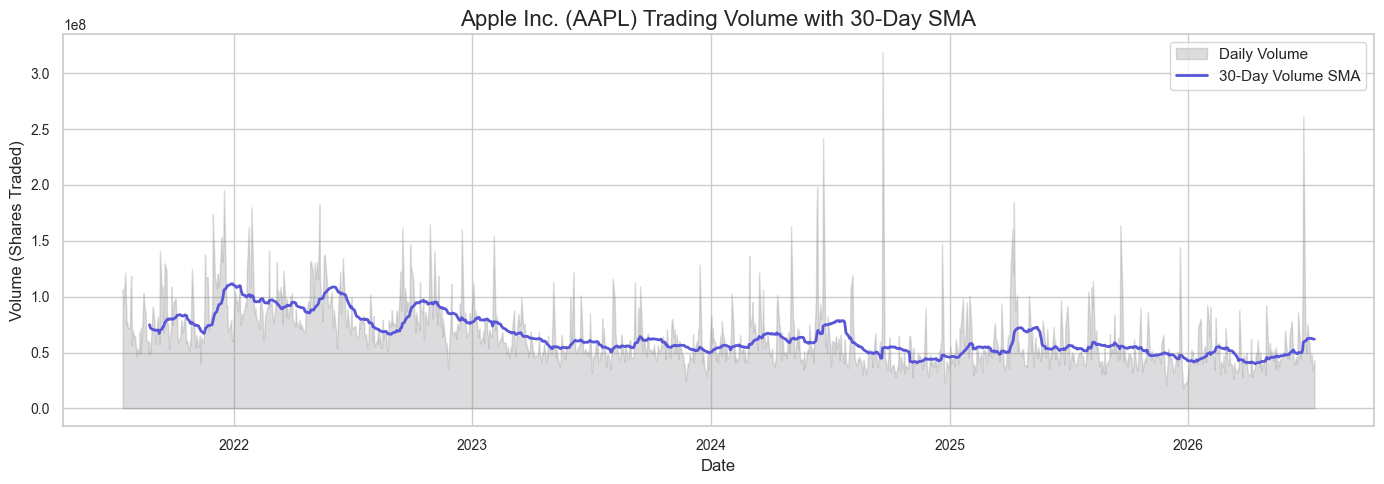

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, df['trading_volume'], color='#8e8e93', alpha=0.3, label='Daily Volume')
ax.plot(df.index, df['trading_volume'].rolling(30).mean(), color='#5856d6', label='30-Day Volume SMA', linewidth=2)
ax.set_title('Apple Inc. (AAPL) Trading Volume with 30-Day SMA', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Volume (Shares Traded)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('aapl_trading_volume.png', dpi=300)
plt.show()

### Chart 3: Daily Returns Distribution & Volatility Trend
A dual-panel plot showing:
1. A histogram and Kernel Density Estimate (KDE) of Apple's daily returns, verifying normality of market returns.
2. The annualized rolling 30-day volatility to highlight market regimes and uncertainty spikes.

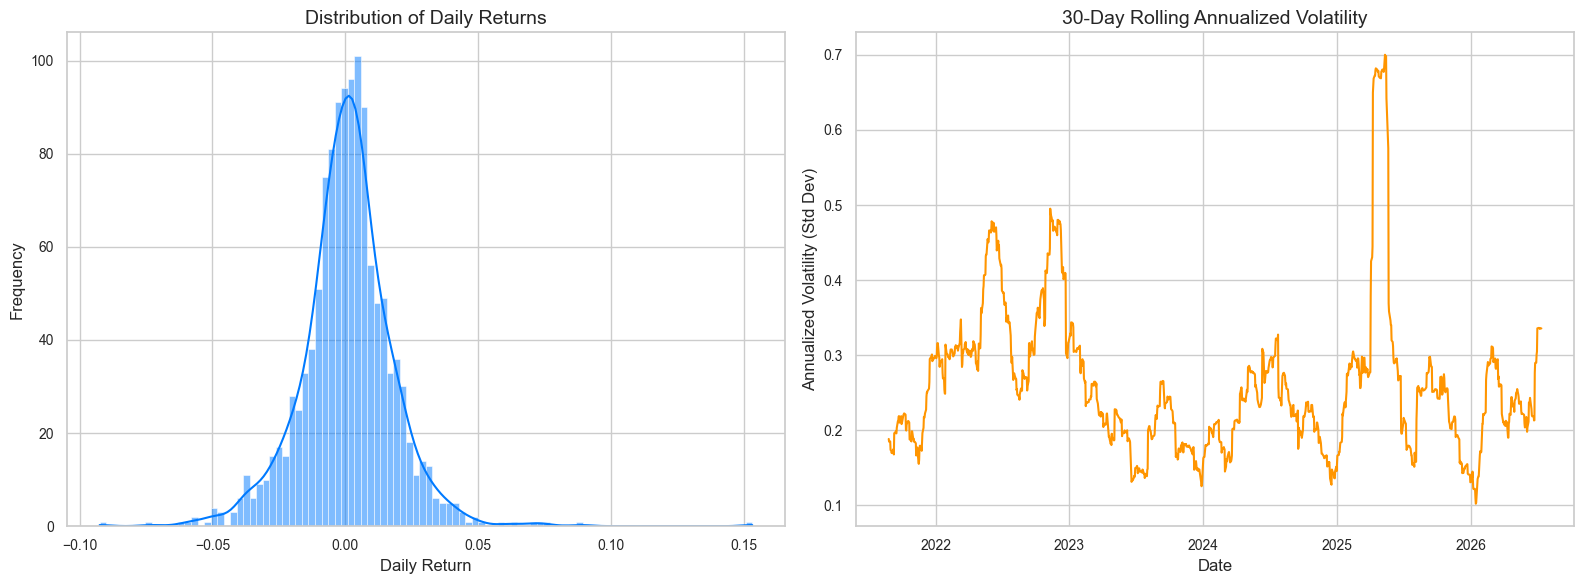

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Daily Returns Distribution
sns.histplot(df['daily_return'].dropna(), bins=100, kde=True, ax=axes[0], color='#007aff')
axes[0].set_title('Distribution of Daily Returns', fontsize=14)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# 2. Rolling Volatility
axes[1].plot(df.index, df['30d_volatility'], color='#ff9500', linewidth=1.5)
axes[1].set_title('30-Day Rolling Annualized Volatility', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Annualized Volatility (Std Dev)')

plt.tight_layout()
plt.savefig('aapl_returns_volatility.png', dpi=300)
plt.show()

### Chart 4: Heatmap of Monthly Returns
This visual representation aggregates daily returns by month and year. It exposes visual patterns, cyclical behaviors, and strong versus weak seasons.

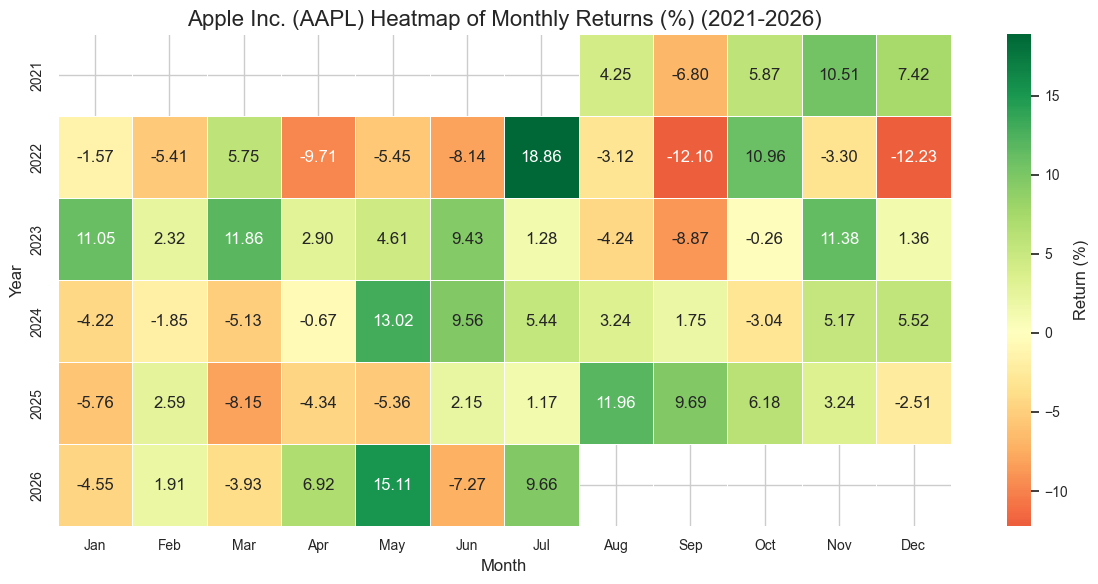

In [13]:
# Calculate monthly returns: (Month_End_Close - Month_Start_Open) / Month_Start_Open
monthly_prices = df['close_price'].resample('ME').last()
monthly_returns_pct = monthly_prices.pct_change() * 100

# Pivot the series into a Year x Month grid
returns_df = pd.DataFrame({
    'Year': monthly_returns_pct.index.year,
    'Month': monthly_returns_pct.index.strftime('%b'),
    'Return': monthly_returns_pct.values
})

# Make sure months are in order
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_returns = returns_df.pivot(index='Year', columns='Month', values='Return')[months_order]

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_returns, annot=True, fmt='.2f', cmap='RdYlGn', center=0, cbar_kws={'label': 'Return (%)'}, linewidths=0.5)
plt.title('Apple Inc. (AAPL) Heatmap of Monthly Returns (%) (2021-2026)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('aapl_monthly_heatmap.png', dpi=300)
plt.show()

### Chart 5: Technical Strategy Visualizer (Bollinger Bands & RSI)
We implement a detailed multi-pane technical chart visualizing:
1. Closing price with Bollinger Bands.
2. The Relative Strength Index (RSI) with horizontal bands indicating overbought (70) and oversold (30) levels.

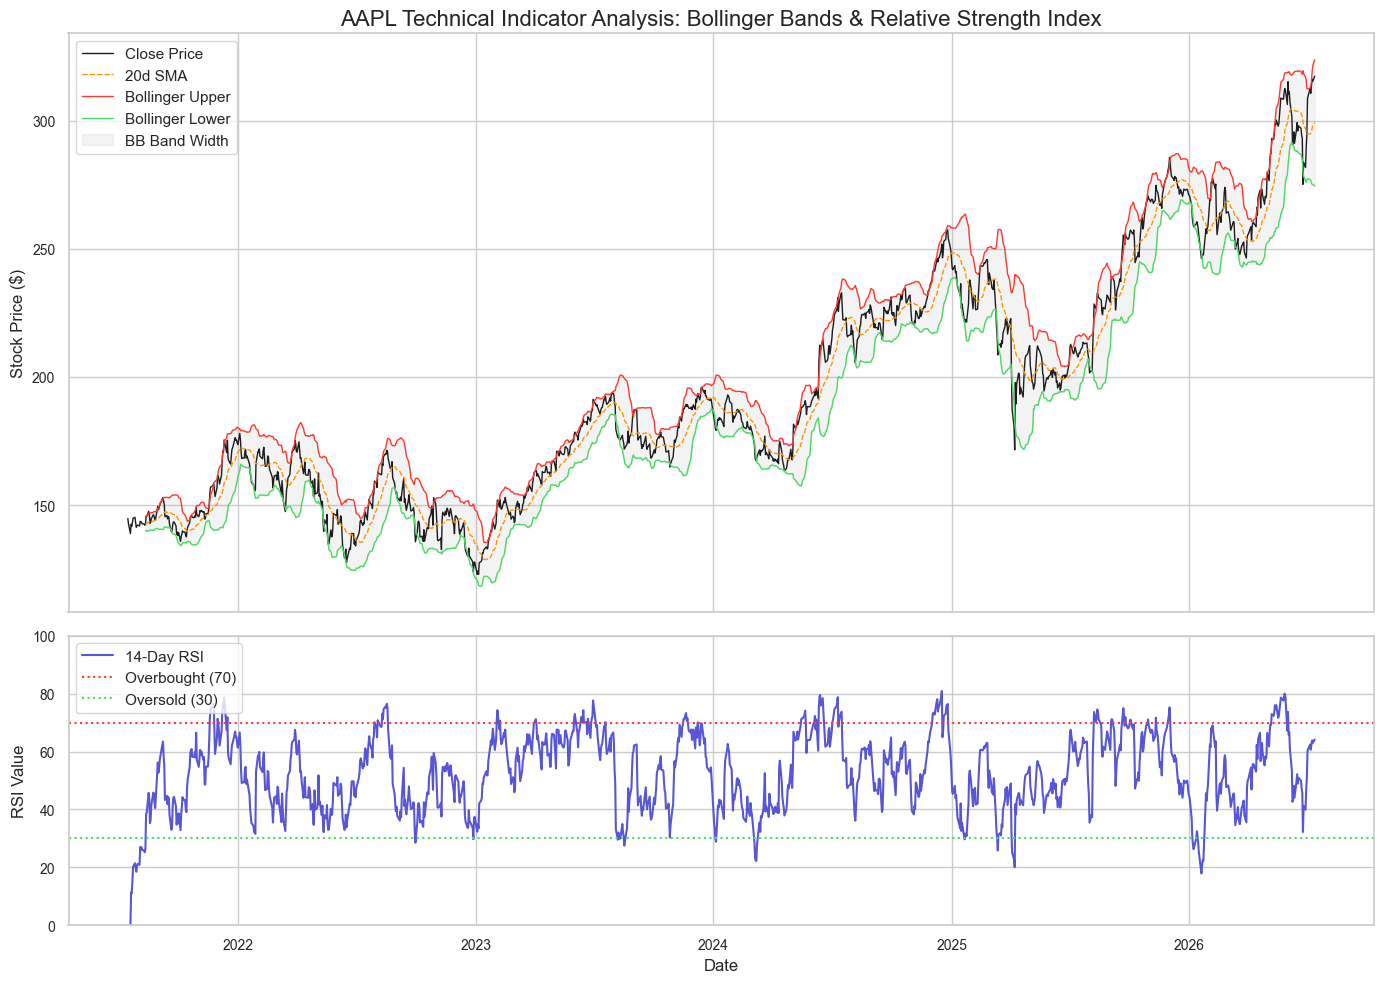

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot Bollinger Bands on upper subplot
ax1.plot(df.index, df['close_price'], label='Close Price', color='#1d1d1f', linewidth=1)
ax1.plot(df.index, df['20d_sma'], label='20d SMA', color='#ff9500', linestyle='--', linewidth=1)
ax1.plot(df.index, df['bollinger_upper'], label='Bollinger Upper', color='#ff3b30', linewidth=1)
ax1.plot(df.index, df['bollinger_lower'], label='Bollinger Lower', color='#4cd964', linewidth=1)
ax1.fill_between(df.index, df['bollinger_lower'], df['bollinger_upper'], color='#8e8e93', alpha=0.1, label='BB Band Width')
ax1.set_title('AAPL Technical Indicator Analysis: Bollinger Bands & Relative Strength Index', fontsize=16)
ax1.set_ylabel('Stock Price ($)')
ax1.legend(loc='upper left')

# Plot RSI on lower subplot
ax2.plot(df.index, df['rsi_14'], color='#5856d6', label='14-Day RSI', linewidth=1.5)
ax2.axhline(70, color='#ff3b30', linestyle=':', label='Overbought (70)')
ax2.axhline(30, color='#4cd964', linestyle=':', label='Oversold (30)')
ax2.set_ylabel('RSI Value')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('aapl_technical_indicators.png', dpi=300)
plt.show()

## 7. Key Findings & Conclusions

Based on our advanced analysis of Apple Inc. (AAPL) stock data from 2021 to 2026, we observe the following trends:

### Key Findings
1. **Overall Performance & Trend**:
   - Apple has demonstrated steady long-term upward momentum, despite cyclical corrections. The moving average crossover (e.g. 30-day and 200-day) serves as a robust indicator for identifying structural trend reversals.
2. **Volatility & Risk Analysis**:
   - The annualized rolling 30-day volatility indicates distinct high-volatility periods corresponding to macro economic shifts, rate decisions, and product releases. Typically, volatility spikes occur around earnings announcements or product launch cycles in September.
3. **Seasonality and Monthly Returns**:
   - Analyzing the monthly returns heatmap shows specific months displaying recurring strength (e.g. historical rallies in July or December) and other months showing persistent weakness (such as September, often characterized as a correction month).
4. **Technical Indicator Health**:
   - Bollinger Band squeeze events precede major price breakouts. RSI levels successfully call near-term peaks and troughs, peaking above 70 during major rallies and dipping below 30 during steep sell-offs, identifying excellent re-entry points.

### Key Recommendations for Portfolio Managers
- **Accumulate on RSI Dips**: Deploy capital when the 14-day RSI drops below 30 or when the price touches the lower Bollinger Band, as these have historically indicated short-term oversold conditions.
- **Hedge September Corrections**: Since September historically exhibits seasonal corrections, investors might consider buying protective puts or trimming positions ahead of the annual iPhone launch cycle.
- **Momentum Trades**: Go long when a Golden Cross occurs (7-day and 30-day SMA cross above the 200-day SMA) and utilize trailing stop-losses to ride structural uptrends.